In [119]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from crowd_counting_hybrid import build_background_from_empty_images, detect_heads_hybrid, ensure_gray

# Configure matplotlib for better visualizations
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

## 1. Invalid Area Mask

In [120]:
import json

json_path: str = '/Dev/Image-and-Video-Analysis/crowd-counting/data/invalid_region.json'
width = 1920
height = 1080

# Load COCO JSON
with open(json_path, "r") as f:
    data = json.load(f)

ann = data["annotations"][0]
poly = np.array(ann["segmentation"][0]).reshape(-1, 2).astype(np.int32)

# Create all-ones mask (valid region)
valid_mask = np.ones((height, width), dtype=np.uint8)

# Fill polygon as invalid region
invalid_region = np.zeros((height, width), dtype=np.uint8)
cv2.fillPoly(invalid_region, [poly], 255)

# Remove invalid region from valid region
valid_mask[invalid_region == 255] = 0  # 0 = invalid, 1 = valid



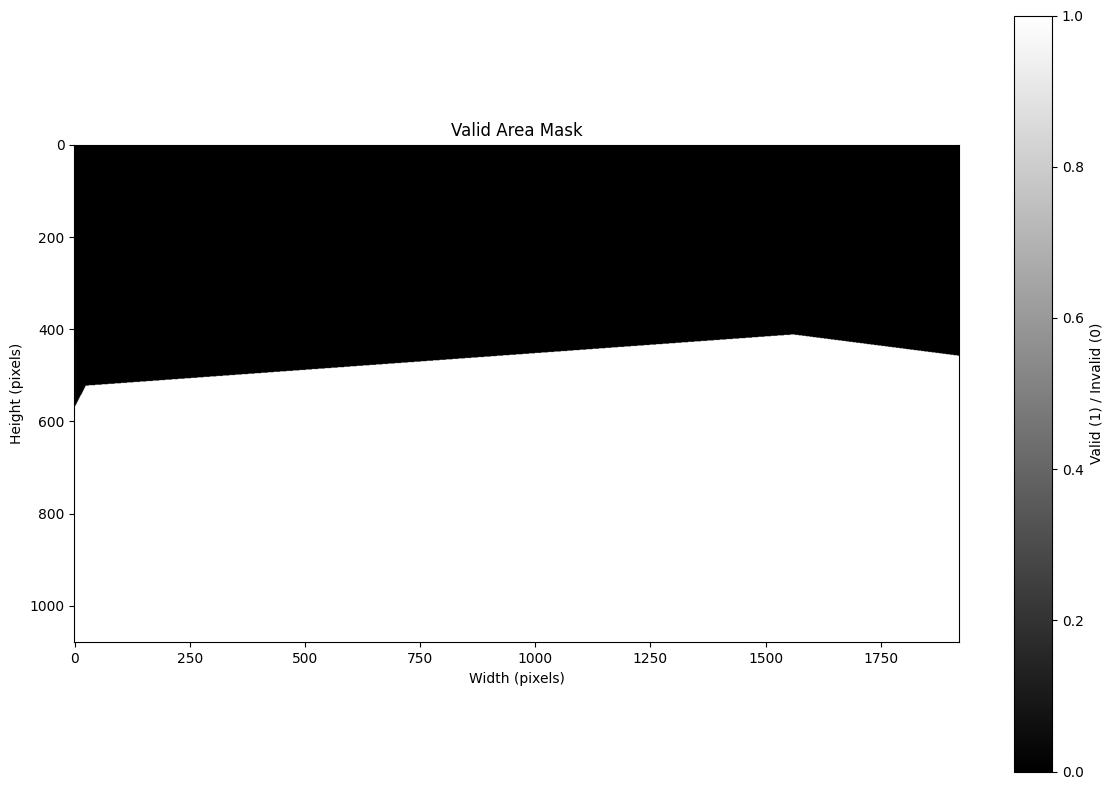

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(valid_mask, cmap='gray')
plt.title('Valid Area Mask')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.colorbar(label='Valid (1) / Invalid (0)')
plt.tight_layout()
plt.show()

## 2. Background Model

In [122]:
import cv2
# --- Setup CLAHE and Gaussian Blur (Optional but recommended) ---
# clipLimit=2.0 is standard; higher values (e.g. 4.0) increase contrast but also noise
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))


In [123]:
import numpy as np

empty_beach_images_paths = [
    '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660798800.jpg',
    '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660802400.jpg'
]

empty_imgs = [img for img in (cv2.imread(p) for p in empty_beach_images_paths) if img is not None]

processed_imgs = []

for im in empty_imgs:
    gray = ensure_gray(im) 
    gray_clahe = clahe.apply(gray)
    gray_blurred = cv2.GaussianBlur(gray_clahe, (5, 5), 0)
    processed_imgs.append(gray_blurred.astype(np.float32))

stacked = np.stack(processed_imgs, axis=0)  
bg = np.mean(stacked, axis=0).astype(np.float32)


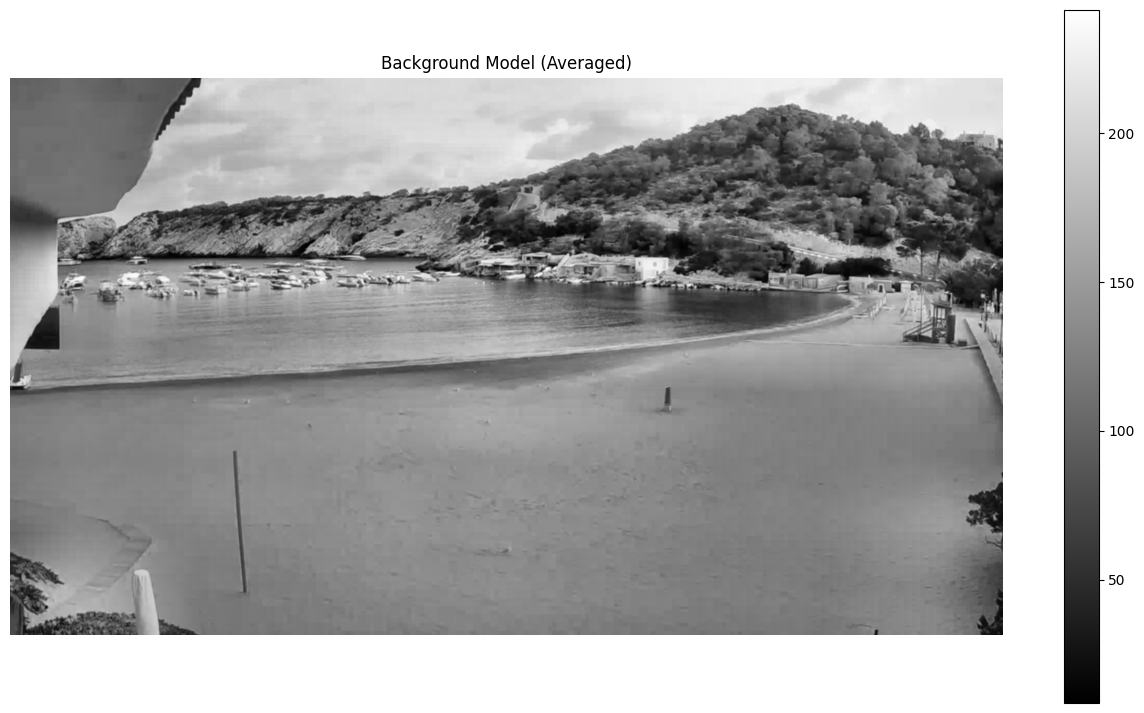

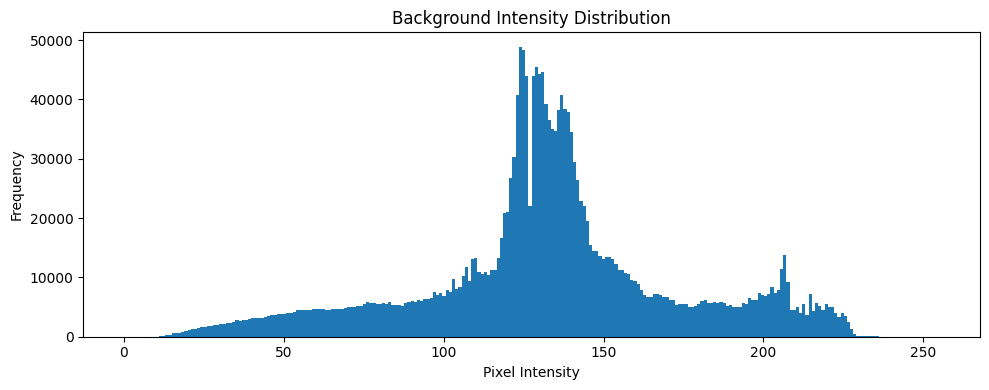

Background shape: (1080, 1920)
Background dtype: float32
Background range: [8.50, 241.50]


In [124]:
# Plot 'Background Model (Averaged)' in full size
plt.figure(figsize=(16, 9))
plt.imshow(bg, cmap='gray')
plt.title('Background Model (Averaged)')
plt.colorbar()
plt.axis('off')
plt.show()

# Plot 'Background Intensity Distribution' separately
plt.figure(figsize=(10, 4))
plt.hist(bg.ravel(), bins=256, range=(0, 255))
plt.title('Background Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Background shape: {bg.shape}")
print(f"Background dtype: {bg.dtype}")
print(f"Background range: [{bg.min():.2f}, {bg.max():.2f}]")

## Test Image preprocessing

In [125]:
test_img = cv2.imread('/Dev/Image-and-Video-Analysis/crowd-counting/data/1660806000.jpg') # 1660806000 1660809600

In [126]:
import cv2
import numpy as np


if test_img is None:
    raise FileNotFoundError("Test image not found.")

hsv = cv2.cvtColor(test_img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
v_enhanced = clahe.apply(v)

hsv_enhanced = cv2.merge([h, s, v_enhanced])

blurred_img = cv2.GaussianBlur(hsv_enhanced, (5, 5), 0)


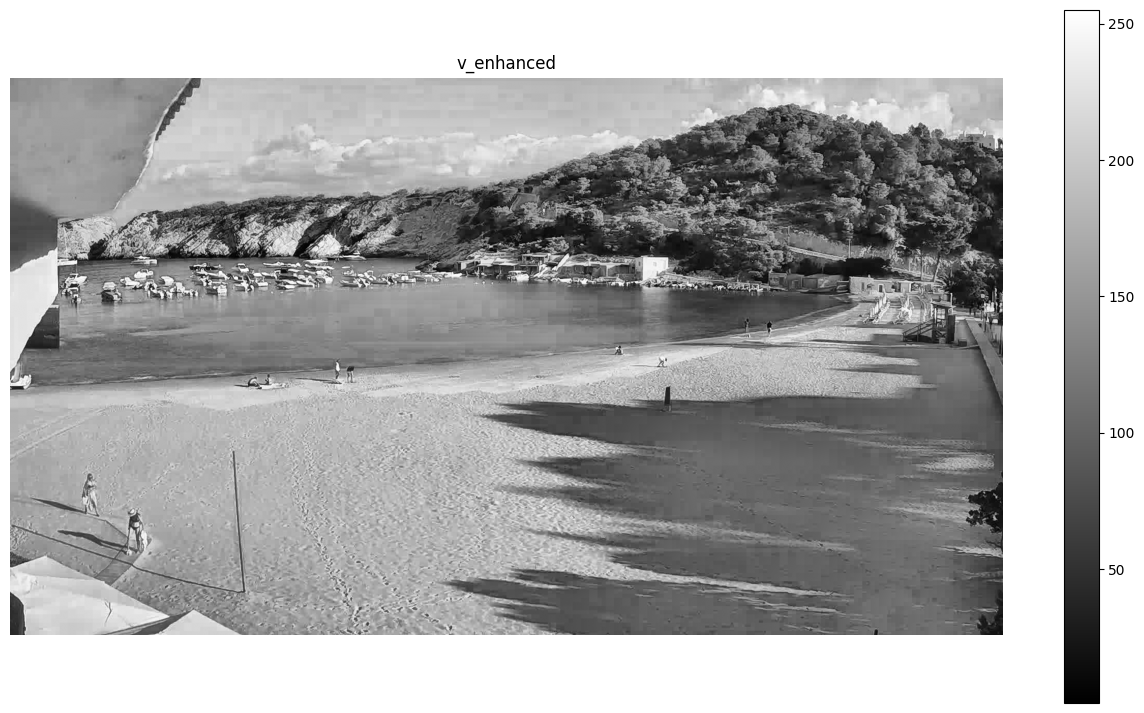

In [127]:
im_to_show =  v_enhanced

plt.figure(figsize=(16, 9))
plt.imshow(im_to_show, cmap='gray')
plt.title('v_enhanced')
plt.colorbar()
plt.axis('off')
plt.show()

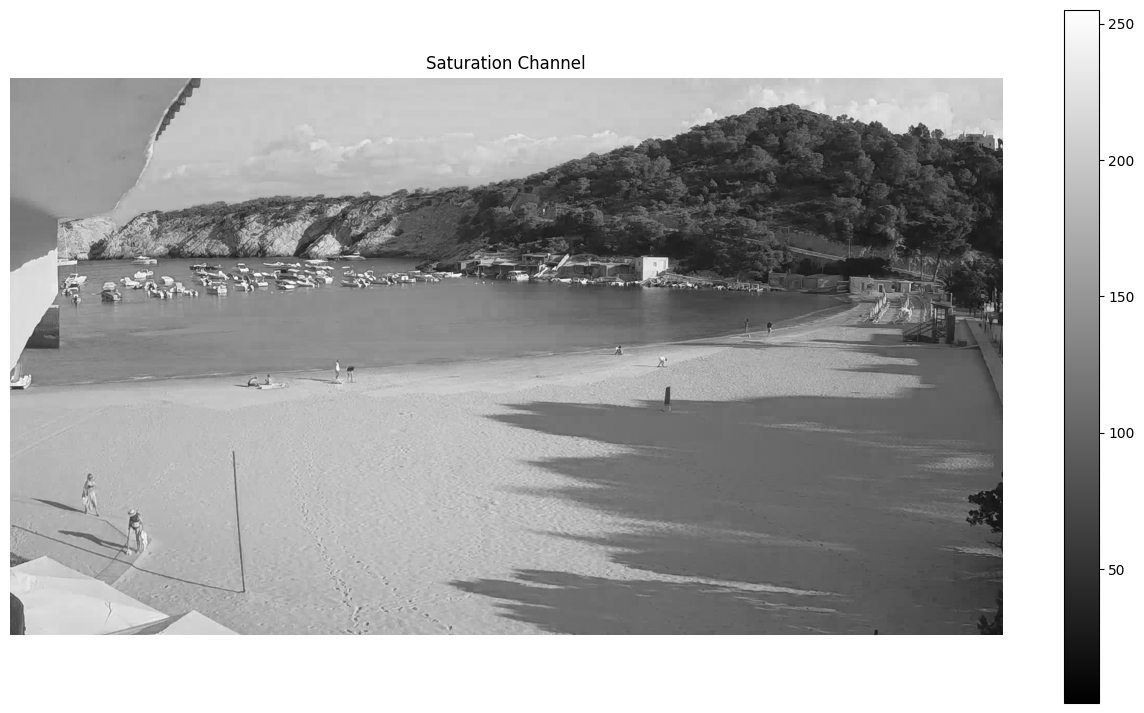

In [128]:
# Convert test image from BGR to HSV

test_hsv = cv2.cvtColor(test_img, cv2.COLOR_BGR2HSV)

# Extract H and S channels
h_channel = test_hsv[:, :, 0]
s_channel = test_hsv[:, :, 1]
v_channel = test_hsv[:, :, 2]

test_img_gray = cv2.GaussianBlur(clahe.apply(v_channel), (5, 5), 0.5).astype(np.float32) 

im_to_show =  test_img_gray

plt.figure(figsize=(16, 9))
plt.imshow(v_channel, cmap='gray')
plt.title('Saturation Channel')
plt.colorbar()
plt.axis('off')
plt.show()


## 3. Background Substraction

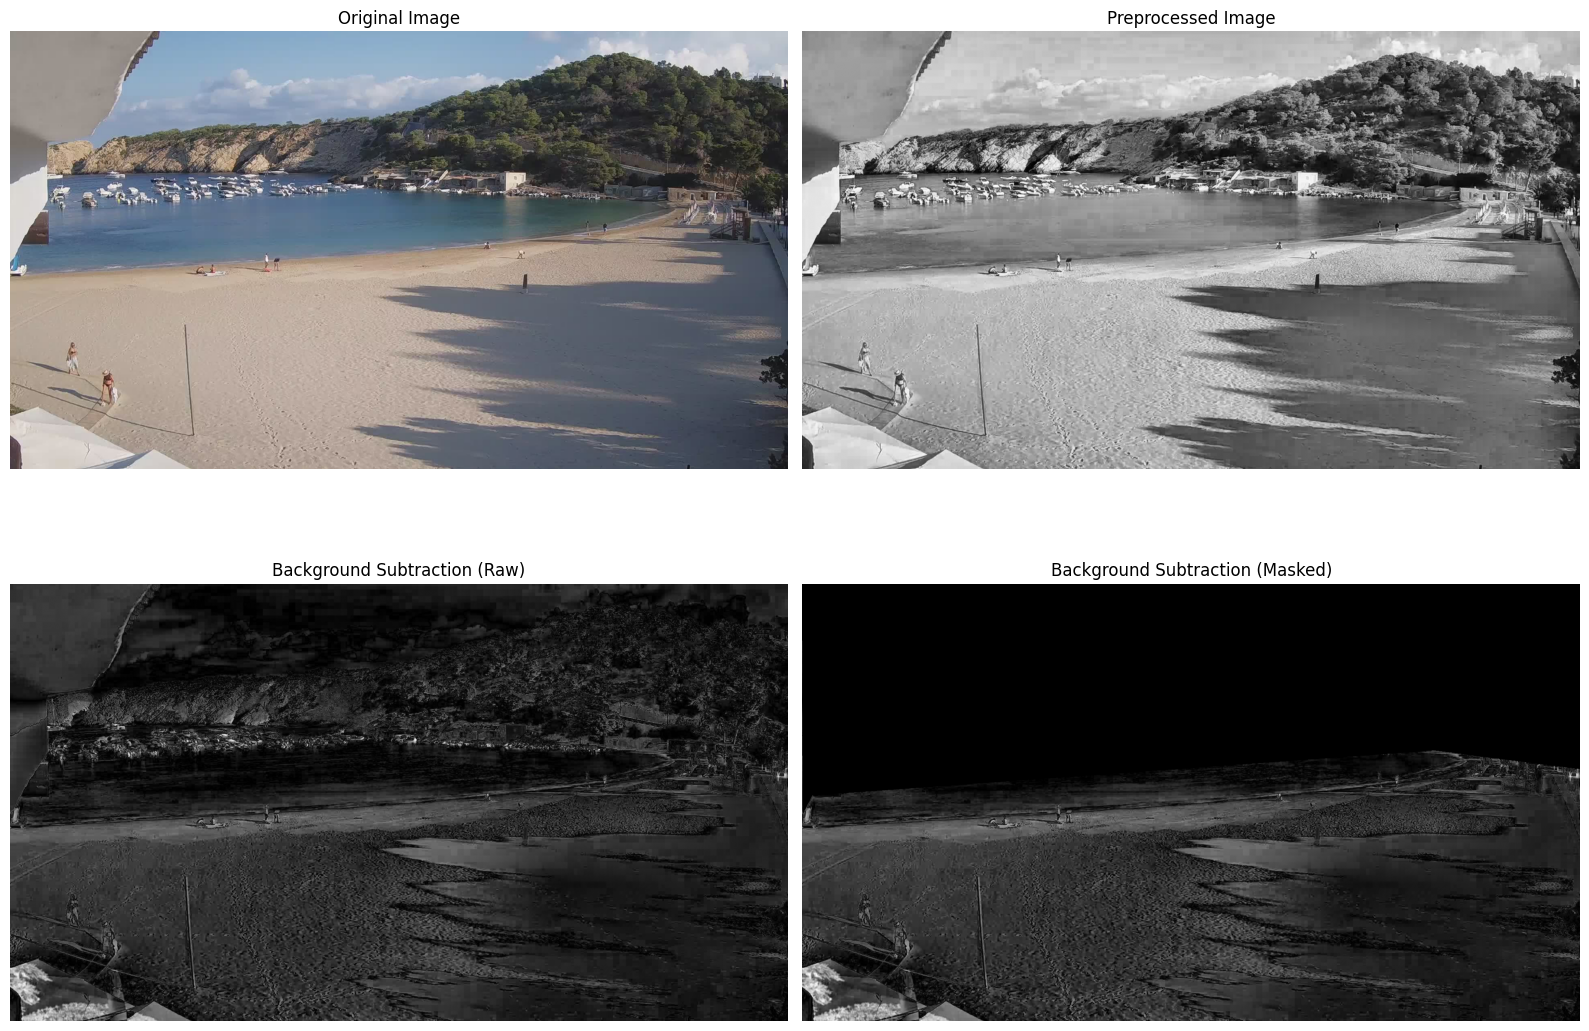

Difference range: [0.00, 217.00]
Masked difference range: [0.00, 208.50]


In [114]:
# Load the test image
test_img = cv2.imread('/Dev/Image-and-Video-Analysis/crowd-counting/data/1660806000.jpg')

if test_img is None:
    raise FileNotFoundError("Test image not found.")

# Preprocess the test image (same as background)
test_gray = ensure_gray(test_img)
test_clahe = clahe.apply(test_gray)
test_blurred = cv2.GaussianBlur(test_clahe, (5, 5), 0.5).astype(np.float32)

# Perform background subtraction
diff = cv2.absdiff(test_img_gray, bg)

# Apply valid mask to remove invalid regions
diff_masked = diff.copy()
diff_masked[valid_mask == 0] = 0

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(test_img_gray, cmap='gray')
axes[0, 1].set_title('Preprocessed Image')
axes[0, 1].axis('off')

axes[1, 0].imshow(diff, cmap='gray')
axes[1, 0].set_title('Background Subtraction (Raw)')
axes[1, 0].axis('off')

axes[1, 1].imshow(diff_masked, cmap='gray')
axes[1, 1].set_title('Background Subtraction (Masked)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Difference range: [{diff.min():.2f}, {diff.max():.2f}]")
print(f"Masked difference range: [{diff_masked.min():.2f}, {diff_masked.max():.2f}]")

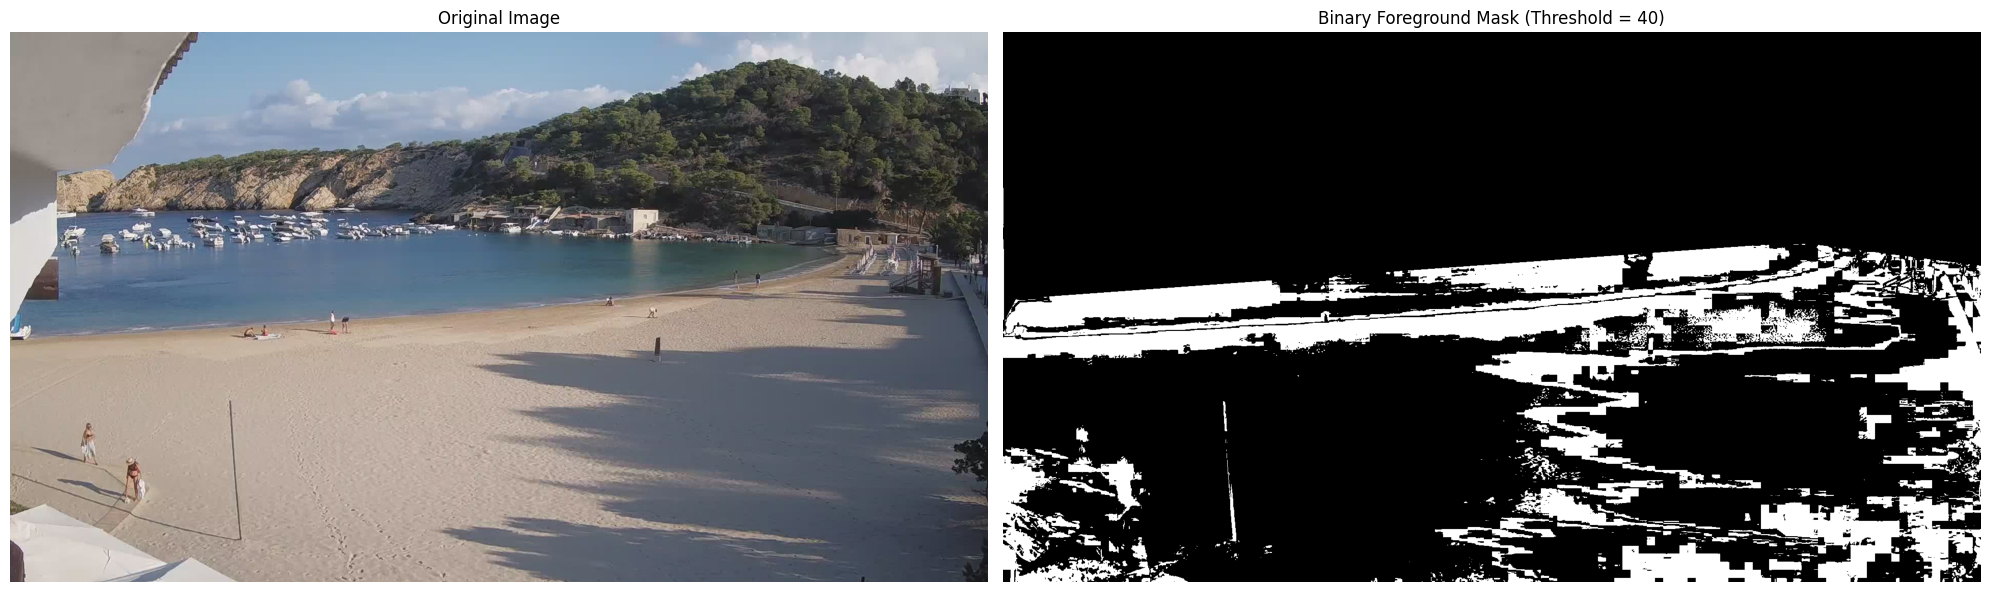

In [112]:
# Apply thresholding to create binary foreground mask
threshold_value = 40

# Adjust based on difference intensity
_, fg_mask = cv2.threshold(diff_masked, threshold_value, 255, cv2.THRESH_BINARY)
fg_mask = fg_mask.astype(np.uint8)

# Visualize binary foreground mask compared to original image
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(fg_mask, cmap='gray')
axes[1].set_title(f'Binary Foreground Mask (Threshold = {threshold_value})')
axes[1].axis('off')

plt.tight_layout()
plt.show()
